In [ ]:
## provided as an extra source
## to be run inside the 1-transaction-data dir

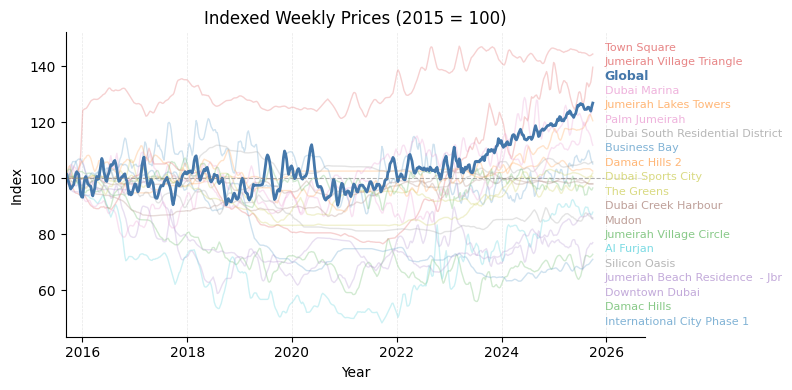

In [ ]:
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

price_csv_path = "price_series.csv"

df_w = pd.read_csv(price_csv_path, parse_dates=["date"])
df_w = df_w.set_index("date")
df_w = df_w.sort_index()

indexed_series = {col: df_w[col].dropna() for col in df_w.columns}

base = mpl.colormaps.get_cmap("tab10")
base_colors = [base(i) for i in range(10)]
pastel_rgba = [(0.3 + 0.7 * r, 0.3 + 0.7 * g, 0.3 + 0.7 * b, 0.8)
               for r, g, b, _ in base_colors]

focus_name = "Global"
focus_color = "#4477AA"

fig, ax = plt.subplots(figsize=(8, 4))

for i, (name, ts) in enumerate(indexed_series.items()):
    is_focus = name == focus_name
    ax.plot(
        ts.index,
        ts.values,
        linewidth=2.0 if is_focus else 1.0,
        alpha=1.0 if is_focus else 0.3,
        color=focus_color if is_focus else pastel_rgba[i % 10]
    )

ax.set_title("Indexed Weekly Prices (2015 = 100)")
ax.set_xlabel("Year")
ax.set_ylabel("Index")
ax.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(y=100, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)

ax.margins(x=0.02)

all_first = min(ts.index.min() for ts in indexed_series.values())
all_last = max(ts.index.max() for ts in indexed_series.values())
ax.set_xlim(all_first, all_last + pd.Timedelta(weeks=52))

sorted_items = sorted(indexed_series.items(), key=lambda item: item[1].iloc[-1])

ymin, ymax = ax.get_ylim()
start = ymin + 0.05 * (ymax - ymin)
end = ymax - 0.05 * (ymax - ymin)
n = len(sorted_items)
step = (end - start) / max(n - 1, 1)
step = min(step, 6)

keys_list = list(indexed_series.keys())

for idx, (name, ts) in enumerate(sorted_items):
    y_final = start + idx * step
    ax.text(
        ts.index[-1] + pd.Timedelta(weeks=12),
        y_final,
        name.title(),
        color=focus_color if name == focus_name
              else pastel_rgba[keys_list.index(name) % 10],
        fontsize=9 if name == focus_name else 8,
        fontweight="bold" if name == focus_name else "normal",
        va="center",
        bbox=dict(boxstyle="round,pad=0.05", facecolor="white", alpha=0.6, edgecolor="none")
    )

fig.tight_layout()

# fig.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()
